<a href="https://colab.research.google.com/github/sandunikapet-ai/sandunikapet-ai/blob/main/Copy_of_Amazon%20Delivery.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
# Upload your sampled dataset
from google.colab import files
uploaded = files.upload()

Saving Amazon_Delivery_15000.csv to Amazon_Delivery_15000.csv


In [4]:
# Install required libraries
!pip install pandas numpy matplotlib seaborn scikit-learn

# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print(" All libraries loaded successfully!")

 All libraries loaded successfully!


In [5]:
df = pd.read_csv('Amazon_Delivery_15000.csv')

print("Total Rows:", len(df))
print("Total Columns:", len(df.columns))

Total Rows: 15000
Total Columns: 16


In [5]:
# See first 10 rows
df.head(10)

,Order_ID,Agent_Age,Agent_Rating,Store_Latitude,Store_Longitude,Drop_Latitude,Drop_Longitude,Order_Date,Order_Time,Pickup_Time,Weather,Traffic,Vehicle,Area,Delivery_Time,Category
0,vvgw032244127,29,4.9,11.000762,76.981876,11.050762,77.031876,2022-03-26,17:15:00,17:30:00,Stormy,Medium,motorcycle,Metropolitian,145,Skincare
1,fvml427733005,33,4.9,22.760072,75.892574,22.870072,76.002574,2022-03-18,17:15:00,17:25:00,Sandstorms,Medium,scooter,Urban,21,Grocery
2,bphh205146945,26,4.7,0.000000,0.000000,0.040000,0.040000,2022-03-21,14:10:00,14:15:00,Fog,High,motorcycle,Metropolitian,165,Toys
3,bdxa651837153,27,4.3,19.223840,72.841347,19.333840,72.951347,2022-03-12,19:10:00,19:15:00,Fog,Jam,motorcycle,Urban,200,Skincare
4,nqdj107406558,20,5.0,13.058616,80.264151,13.108616,80.314151,2022-03-19,21:35:00,21:45:00,Fog,Jam,van,Metropolitian,145,Cosmetics
5,mrjk286419068,31,5.0,18.546258,73.904337,18.616258,73.974337,2022-03-06,22:00:00,22:05:00,Sunny,Jam,motorcycle,Metropolitian,180,Toys
6,rcza819727189,24,4.8,12.972161,77.596014,13.032161,77.656014,2022-03-19,21:15:00,21:25:00,Cloudy,Jam,scooter,Metropolitian,120,Jewelry
7,hqun420775402,33,4.9,11.021278,76.995017,11.151278,77.125017,2022-03-12,17:40:00,17:55:00,Fog,Medium,motorcycle,Metropolitian,180,Snacks
8,ulzo372690469,20,4.3,0.000000,0.000000,0.110000,0.110000,2022-03-23,18:15:00,18:25:00,Cloudy,Medium,scooter,Metropolitian,155,Clothing
9,evgj038305492,28,4.2,22.732225,75.874765,22.742225,75.884765,2022-03-11,08:15:00,08:25:00,Sandstorms,Low,motorcycle,Metropolitian,85,Kitchen


In [6]:
print(df.dtypes)

Order_ID            object
Agent_Age            int64
Agent_Rating       float64
Store_Latitude     float64
Store_Longitude    float64
Drop_Latitude      float64
Drop_Longitude     float64
Order_Date          object
Order_Time          object
Pickup_Time         object
Weather             object
Traffic             object
Vehicle             object
Area                object
Delivery_Time        int64
Category            object
dtype: object


In [7]:
df.describe()

,Agent_Age,Agent_Rating,Store_Latitude,Store_Longitude,Drop_Latitude,Drop_Longitude,Delivery_Time
count,15000.000000,14983.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,29.554933,4.633425,17.154722,70.766329,17.392020,70.922387,124.606533
std,5.824160,0.337725,7.713996,21.342173,7.316290,21.032548,51.737631
min,15.000000,1.000000,-30.899584,-80.318656,0.010000,0.010000,10.000000
25%,25.000000,4.500000,12.933284,73.749092,12.974264,73.781991,90.000000
50%,30.000000,4.700000,18.546258,75.903365,18.616947,76.019490,125.000000
75%,35.000000,4.900000,22.728163,78.044095,22.781234,78.095129,160.000000
max,50.000000,6.000000,30.914057,88.433452,31.045562,88.563452,270.000000


In [8]:
missing = df.isnull().sum()
missing_percent = (df.isnull().sum() / len(df)) * 100

missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing Percentage': missing_percent
})

print(missing_df[missing_df['Missing Count'] > 0])

              Missing Count  Missing Percentage
Agent_Rating             17            0.113333
Weather                  36            0.240000


In [9]:
duplicates = df.duplicated().sum()
print(f"Total duplicate rows: {duplicates}")

Total duplicate rows: 0


In [10]:
# Check ALL column names in your dataset
print("Your actual column names are:")
print(df.columns.tolist())

Your actual column names are:
['Order_ID', 'Agent_Age', 'Agent_Rating', 'Store_Latitude', 'Store_Longitude', 'Drop_Latitude', 'Drop_Longitude', 'Order_Date', 'Order_Time', 'Pickup_Time', 'Weather', 'Traffic', 'Vehicle', 'Area', 'Delivery_Time', 'Category']


In [11]:
print(df['Delivery_Time'].value_counts())
print("\nData type:", df['Delivery_Time'].dtype)
print("\nSample values:", df['Delivery_Time'].head(10).tolist())

Delivery_Time
125    663
130    651
140    638
145    622
135    592
      ... 
48       5
51       4
54       3
53       2
52       1
Name: count, Length: 89, dtype: int64

Data type: int64

Sample values: [145, 21, 165, 200, 145, 180, 120, 180, 155, 85]


In [12]:
# Check the distribution of Delivery_Time
print("=== DELIVERY TIME STATISTICS ===")
print(f"Minimum: {df['Delivery_Time'].min()} minutes")
print(f"Maximum: {df['Delivery_Time'].max()} minutes")
print(f"Average: {df['Delivery_Time'].mean():.2f} minutes")
print(f"Median: {df['Delivery_Time'].median()} minutes")

=== DELIVERY TIME STATISTICS ===
Minimum: 10 minutes
Maximum: 270 minutes
Average: 124.61 minutes
Median: 125.0 minutes


=== DELIVERY STATUS DISTRIBUTION ===
Delivery_Status
Delayed    7675
On-Time    7325
Name: count, dtype: int64

Percentage:
Delivery_Status
Delayed    51.17
On-Time    48.83
Name: proportion, dtype: float64


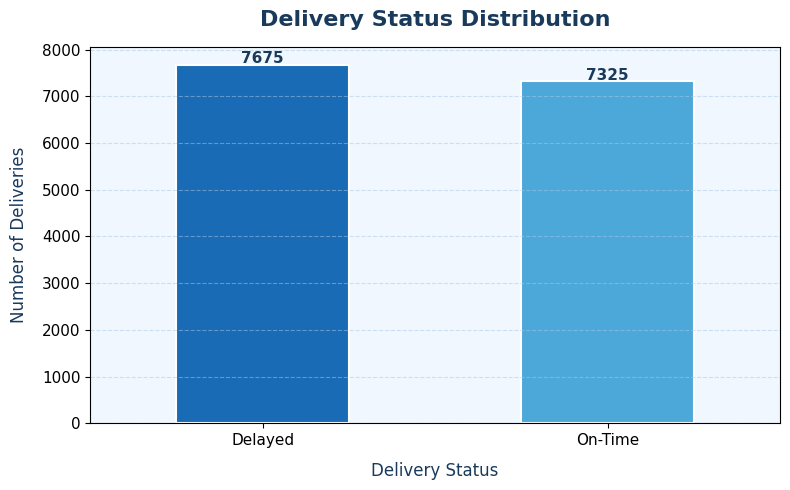

In [13]:
# Create Delivery_Status based on Delivery_Time
df['Delivery_Status'] = df['Delivery_Time'].apply(
    lambda x: 'Delayed' if x > 120 else 'On-Time'
)

# Check the result
print("=== DELIVERY STATUS DISTRIBUTION ===")
print(df['Delivery_Status'].value_counts())
print("\nPercentage:")
print((df['Delivery_Status'].value_counts(normalize=True) * 100).round(2))

# Plot with beautiful blue mix colours
plt.figure(figsize=(8,5))

# Nice blue mix colours
colors = ['#1A6BB5', '#4DA8DA']

df['Delivery_Status'].value_counts().plot(
    kind='bar',
    color=colors,
    edgecolor='white',
    linewidth=1.5,
    width=0.5
)

# Styling
plt.title('Delivery Status Distribution',
          fontsize=16,
          fontweight='bold',
          color='#1A3A5C',
          pad=15)
plt.xlabel('Delivery Status',
           fontsize=12,
           color='#1A3A5C',
           labelpad=10)
plt.ylabel('Number of Deliveries',
           fontsize=12,
           color='#1A3A5C',
           labelpad=10)
plt.xticks(rotation=0, fontsize=11)
plt.yticks(fontsize=11)

# Add count labels on top of bars
for i, v in enumerate(df['Delivery_Status'].value_counts()):
    plt.text(i, v + 30, str(v),
             ha='center',
             fontweight='bold',
             fontsize=11,
             color='#1A3A5C')

# Add grid for readability
plt.grid(axis='y',
         linestyle='--',
         alpha=0.5,
         color='#A8C8E8')

# Background colour
plt.gca().set_facecolor('#F0F7FF')
plt.gcf().set_facecolor('#FFFFFF')

plt.tight_layout()
plt.show()

In [14]:
# ============================================
# GLOBAL BLUE & PURPLE COLOUR THEME
# ============================================

# Colour palette
COLORS = [
    '#1A6BB5',  # Deep Blue
    '#7B2D8B',  # Deep Purple
    '#4DA8DA',  # Medium Blue
    '#9C27B0',  # Medium Purple
    '#2196F3',  # Bright Blue
    '#CE93D8',  # Light Purple
    '#90CAF9',  # Light Blue
    '#4A148C',  # Dark Purple
    '#1565C0',  # Royal Blue
    '#AB47BC',  # Soft Purple
]

# Apply globally to all charts
plt.rcParams['figure.facecolor'] = '#FFFFFF'
plt.rcParams['axes.facecolor'] = '#F8F4FF'
plt.rcParams['axes.labelcolor'] = '#1A3A5C'
plt.rcParams['xtick.color'] = '#1A3A5C'
plt.rcParams['ytick.color'] = '#1A3A5C'
plt.rcParams['text.color'] = '#1A3A5C'
plt.rcParams['grid.color'] = '#C5B8F0'
plt.rcParams['grid.linestyle'] = '--'
plt.rcParams['grid.alpha'] = 0.5
plt.rcParams['font.family'] = 'DejaVu Sans'

print("✅ Blue & Purple theme applied!")

✅ Blue & Purple theme applied!


=== WEATHER IMPACT ON DELIVERY ===
Delivery_Status  Delayed  On-Time
Weather                          
Cloudy              1483     1025
Fog                 1537     1078
Sandstorms          1314     1127
Stormy              1377     1176
Sunny                650     1768
Windy               1297     1132

Percentage by Weather:
Delivery_Status  Delayed  On-Time
Weather                          
Cloudy             59.13    40.87
Fog                58.78    41.22
Sandstorms         53.83    46.17
Stormy             53.94    46.06
Sunny              26.88    73.12
Windy              53.40    46.60


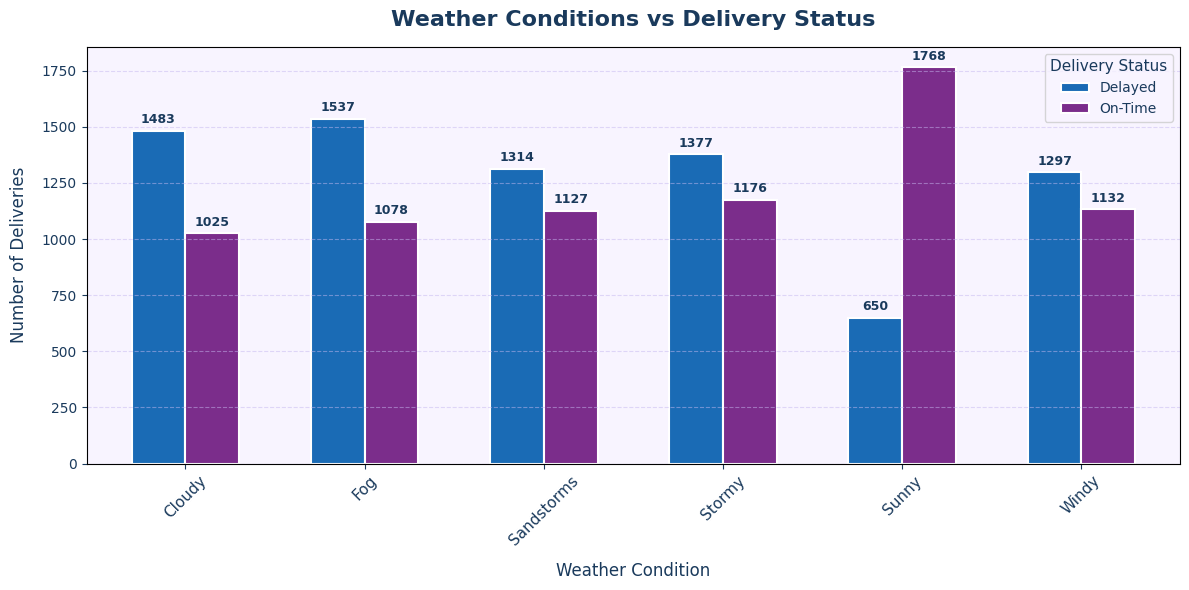

In [15]:
# Weather vs Delivery Status

print("=== WEATHER IMPACT ON DELIVERY ===")

# Group data
weather_delay = df.groupby(
    ['Weather', 'Delivery_Status']
).size().unstack()

print(weather_delay)
print("\nPercentage by Weather:")
print((weather_delay.div(weather_delay.sum(axis=1), axis=0) * 100).round(2))

# Plot
ax = weather_delay.plot(
    kind='bar',
    figsize=(12, 6),
    color=['#1A6BB5', '#7B2D8B'],
    edgecolor='white',
    linewidth=1.5,
    width=0.6
)

# Styling
plt.title('Weather Conditions vs Delivery Status',
          fontsize=16,
          fontweight='bold',
          color='#1A3A5C',
          pad=15)
plt.xlabel('Weather Condition',
           fontsize=12,
           color='#1A3A5C',
           labelpad=10)
plt.ylabel('Number of Deliveries',
           fontsize=12,
           color='#1A3A5C',
           labelpad=10)
plt.xticks(rotation=45, fontsize=11)
plt.legend(title='Delivery Status',
           title_fontsize=11,
           fontsize=10,
           loc='upper right')
plt.grid(axis='y', linestyle='--', alpha=0.5, color='#C5B8F0')
plt.gca().set_facecolor('#F8F4FF')

# Add value labels on bars
for container in ax.containers:
    ax.bar_label(container,
                 fontsize=9,
                 fontweight='bold',
                 color='#1A3A5C',
                 padding=3)

plt.tight_layout()
plt.show()

=== TRAFFIC IMPACT ON DELIVERY ===
Delivery_Status  Delayed  On-Time
Traffic                          
High                 885      559
Jam                 3292     1480
Low                 1471     3667
Medium              2010     1600
NaN                   17       19

Percentage by Traffic Level:
Delivery_Status  Delayed  On-Time
Traffic                          
High               61.29    38.71
Jam                68.99    31.01
Low                28.63    71.37
Medium             55.68    44.32
NaN                47.22    52.78


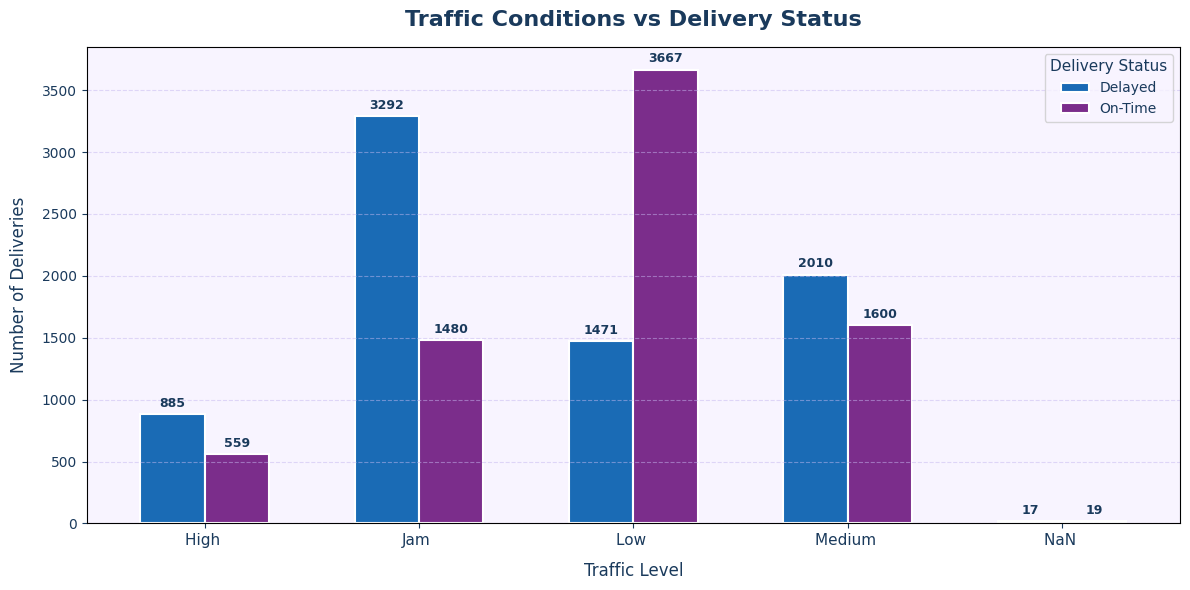

In [16]:
print("=== TRAFFIC IMPACT ON DELIVERY ===")

# Group data
traffic_delay = df.groupby(
    ['Traffic', 'Delivery_Status']
).size().unstack()

print(traffic_delay)
print("\nPercentage by Traffic Level:")
print((traffic_delay.div(traffic_delay.sum(axis=1), axis=0) * 100).round(2))

# Plot
ax = traffic_delay.plot(
    kind='bar',
    figsize=(12, 6),
    color=['#1A6BB5', '#7B2D8B'],
    edgecolor='white',
    linewidth=1.5,
    width=0.6
)

# Styling
plt.title('Traffic Conditions vs Delivery Status',
          fontsize=16,
          fontweight='bold',
          color='#1A3A5C',
          pad=15)
plt.xlabel('Traffic Level',
           fontsize=12,
           color='#1A3A5C',
           labelpad=10)
plt.ylabel('Number of Deliveries',
           fontsize=12,
           color='#1A3A5C',
           labelpad=10)
plt.xticks(rotation=0, fontsize=11)
plt.legend(title='Delivery Status',
           title_fontsize=11,
           fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.5, color='#C5B8F0')
plt.gca().set_facecolor('#F8F4FF')

# Add value labels
for container in ax.containers:
    ax.bar_label(container,
                 fontsize=9,
                 fontweight='bold',
                 color='#1A3A5C',
                 padding=3)

plt.tight_layout()
plt.show()

=== VEHICLE TYPE IMPACT ===
Delivery_Status  Delayed  On-Time
Vehicle                          
bicycle                2        4
motorcycle          4823     3938
scooter             2301     2708
van                  549      675

Percentage by Vehicle Type:
Delivery_Status  Delayed  On-Time
Vehicle                          
bicycle            33.33    66.67
motorcycle         55.05    44.95
scooter            45.94    54.06
van                44.85    55.15


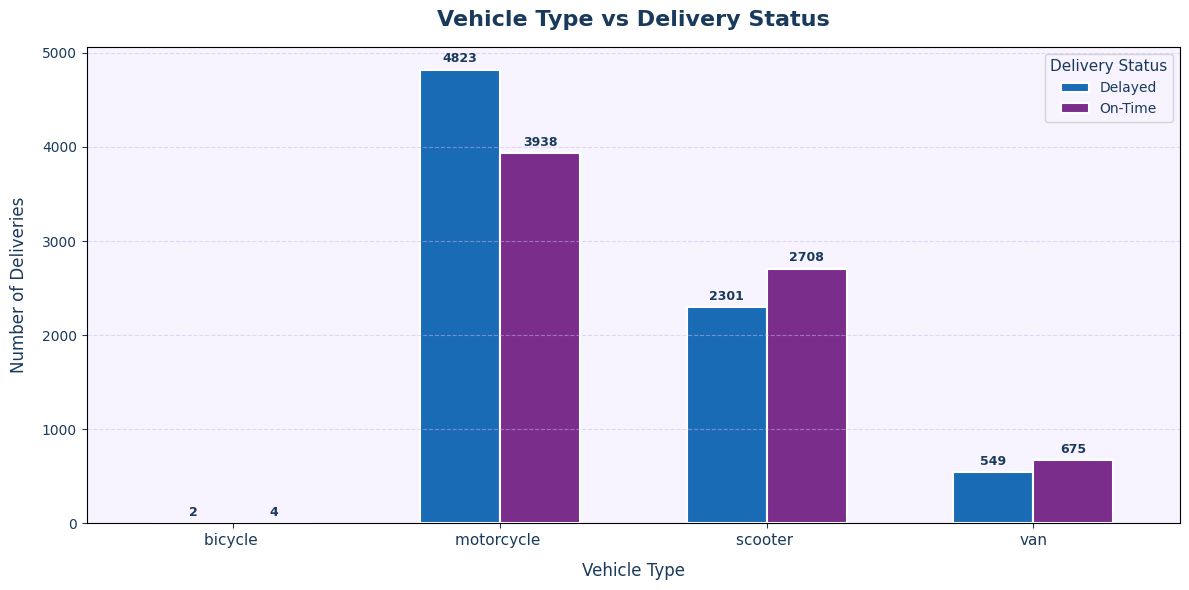

In [17]:
print("=== VEHICLE TYPE IMPACT ===")

# Group data
vehicle_delay = df.groupby(
    ['Vehicle', 'Delivery_Status']
).size().unstack()

print(vehicle_delay)
print("\nPercentage by Vehicle Type:")
print((vehicle_delay.div(vehicle_delay.sum(axis=1), axis=0) * 100).round(2))

# Plot
ax = vehicle_delay.plot(
    kind='bar',
    figsize=(12, 6),
    color=['#1A6BB5', '#7B2D8B'],
    edgecolor='white',
    linewidth=1.5,
    width=0.6
)

# Styling
plt.title('Vehicle Type vs Delivery Status',
          fontsize=16,
          fontweight='bold',
          color='#1A3A5C',
          pad=15)
plt.xlabel('Vehicle Type',
           fontsize=12,
           color='#1A3A5C',
           labelpad=10)
plt.ylabel('Number of Deliveries',
           fontsize=12,
           color='#1A3A5C',
           labelpad=10)
plt.xticks(rotation=0, fontsize=11)
plt.legend(title='Delivery Status',
           title_fontsize=11,
           fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.5, color='#C5B8F0')
plt.gca().set_facecolor('#F8F4FF')

# Add value labels
for container in ax.containers:
    ax.bar_label(container,
                 fontsize=9,
                 fontweight='bold',
                 color='#1A3A5C',
                 padding=3)

plt.tight_layout()
plt.show()

=== AREA IMPACT (URBAN vs RURAL) ===
Delivery_Status  Delayed  On-Time
Area                             
Metropolitian       6260     4948
Other                137      235
Semi-Urban            48        2
Urban               1230     2140

Percentage by Area:
Delivery_Status  Delayed  On-Time
Area                             
Metropolitian      55.85    44.15
Other              36.83    63.17
Semi-Urban         96.00     4.00
Urban              36.50    63.50


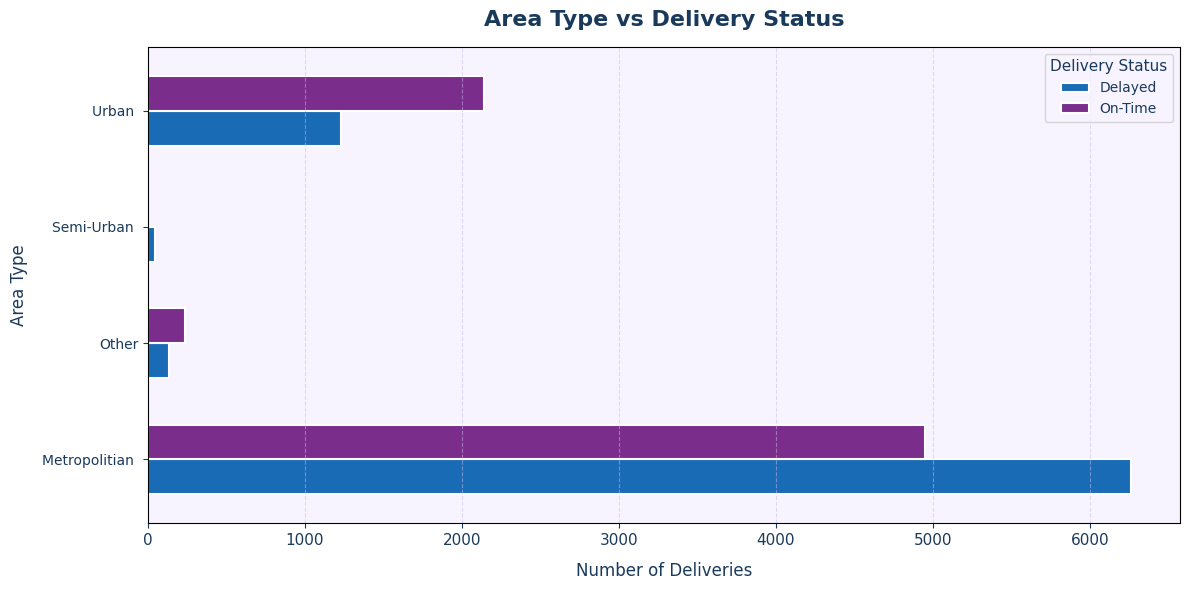

In [18]:
print("=== AREA IMPACT (URBAN vs RURAL) ===")

# Group data
area_delay = df.groupby(
    ['Area', 'Delivery_Status']
).size().unstack()

print(area_delay)
print("\nPercentage by Area:")
print((area_delay.div(area_delay.sum(axis=1), axis=0) * 100).round(2))

# Plot - Horizontal bar for variety
ax = area_delay.plot(
    kind='barh',
    figsize=(12, 6),
    color=['#1A6BB5', '#7B2D8B'],
    edgecolor='white',
    linewidth=1.5,
    width=0.6
)

# Styling
plt.title('Area Type vs Delivery Status',
          fontsize=16,
          fontweight='bold',
          color='#1A3A5C',
          pad=15)
plt.xlabel('Number of Deliveries',
           fontsize=12,
           color='#1A3A5C',
           labelpad=10)
plt.ylabel('Area Type',
           fontsize=12,
           color='#1A3A5C',
           labelpad=10)
plt.xticks(rotation=0, fontsize=11)
plt.legend(title='Delivery Status',
           title_fontsize=11,
           fontsize=10)
plt.grid(axis='x', linestyle='--', alpha=0.5, color='#C5B8F0')
plt.gca().set_facecolor('#F8F4FF')

plt.tight_layout()
plt.show()

=== AGENT PERFORMANCE ANALYSIS ===

Average Agent Rating by Delivery Status:
Delivery_Status
Delayed    4.55
On-Time    4.72
Name: Agent_Rating, dtype: float64

Average Agent Age by Delivery Status:
Delivery_Status
Delayed    31.04
On-Time    28.00
Name: Agent_Age, dtype: float64


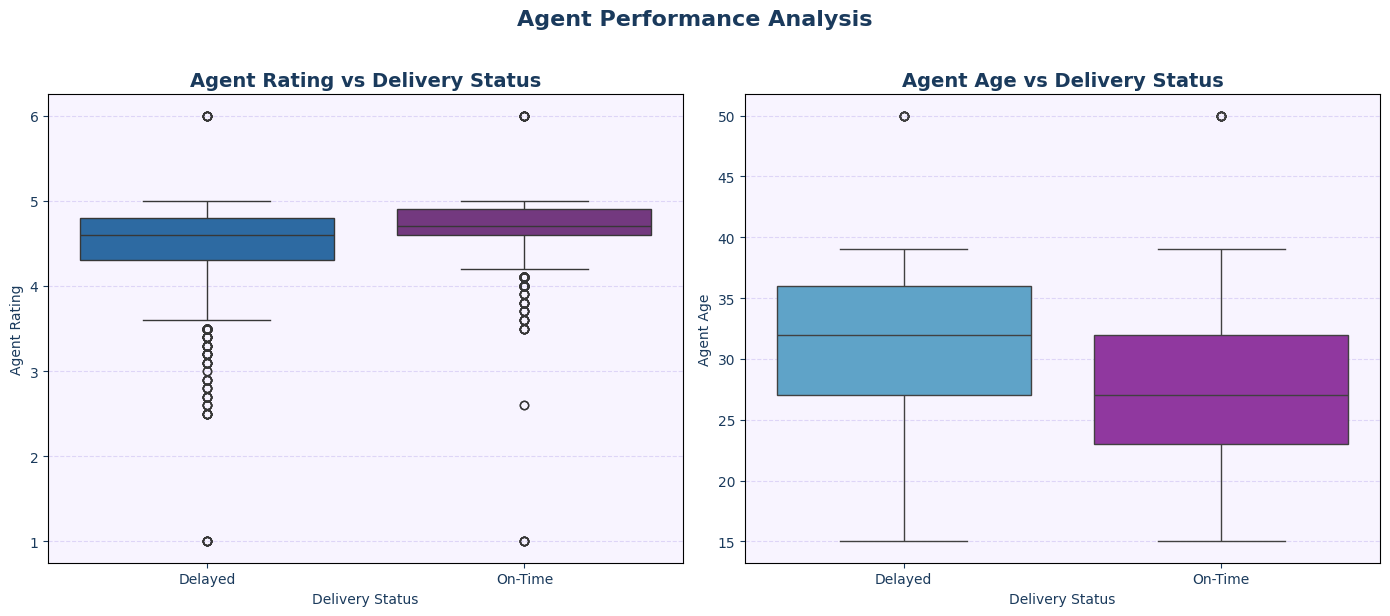

In [19]:
print("=== AGENT PERFORMANCE ANALYSIS ===")
print("\nAverage Agent Rating by Delivery Status:")
print(df.groupby('Delivery_Status')['Agent_Rating'].mean().round(2))

print("\nAverage Agent Age by Delivery Status:")
print(df.groupby('Delivery_Status')['Agent_Age'].mean().round(2))

# Plot 1 - Agent Rating Box Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.patch.set_facecolor('#FFFFFF')

# Agent Rating
sns.boxplot(
    x='Delivery_Status',
    y='Agent_Rating',
    data=df,
    palette=['#1A6BB5', '#7B2D8B'],
    ax=axes[0]
)
axes[0].set_title('Agent Rating vs Delivery Status',
                   fontsize=14,
                   fontweight='bold',
                   color='#1A3A5C')
axes[0].set_xlabel('Delivery Status', color='#1A3A5C')
axes[0].set_ylabel('Agent Rating', color='#1A3A5C')
axes[0].set_facecolor('#F8F4FF')
axes[0].grid(axis='y', linestyle='--', alpha=0.5, color='#C5B8F0')

# Agent Age
sns.boxplot(
    x='Delivery_Status',
    y='Agent_Age',
    data=df,
    palette=['#4DA8DA', '#9C27B0'],
    ax=axes[1]
)
axes[1].set_title('Agent Age vs Delivery Status',
                   fontsize=14,
                   fontweight='bold',
                   color='#1A3A5C')
axes[1].set_xlabel('Delivery Status', color='#1A3A5C')
axes[1].set_ylabel('Agent Age', color='#1A3A5C')
axes[1].set_facecolor('#F8F4FF')
axes[1].grid(axis='y', linestyle='--', alpha=0.5, color='#C5B8F0')

plt.suptitle('Agent Performance Analysis',
             fontsize=16,
             fontweight='bold',
             color='#1A3A5C',
             y=1.02)
plt.tight_layout()
plt.show()

=== PRODUCT CATEGORY ANALYSIS ===
Delivery_Status  Delayed  On-Time
Category                         
Apparel            533.0    422.0
Books              555.0    447.0
Clothing           458.0    452.0
Cosmetics          529.0    422.0
Electronics        553.0    439.0
Grocery              NaN    916.0
Home               519.0    437.0
Jewelry            511.0    404.0
Kitchen            512.0    389.0
Outdoors           503.0    433.0
Pet Supplies       483.0    418.0
Shoes              512.0    422.0
Skincare           489.0    436.0
Snacks             523.0    425.0
Sports             516.0    421.0
Toys               479.0    442.0


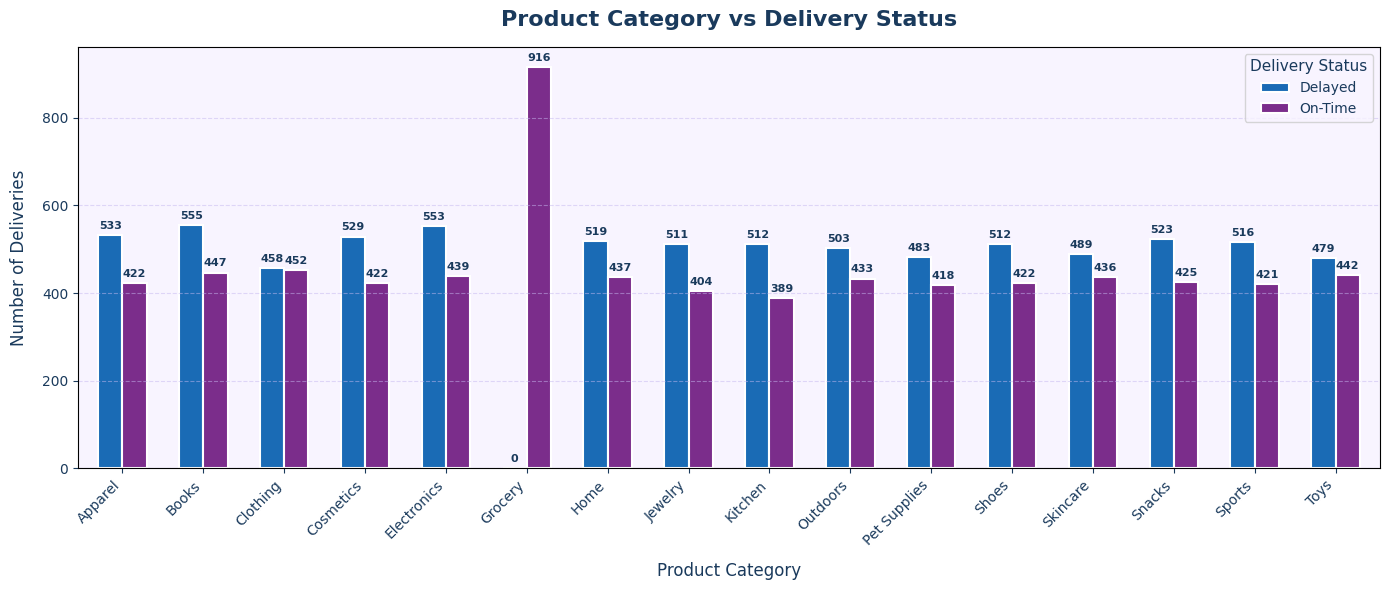

In [20]:
print("=== PRODUCT CATEGORY ANALYSIS ===")

# Group data
category_delay = df.groupby(
    ['Category', 'Delivery_Status']
).size().unstack()

print(category_delay)

# Plot
ax = category_delay.plot(
    kind='bar',
    figsize=(14, 6),
    color=['#1A6BB5', '#7B2D8B'],
    edgecolor='white',
    linewidth=1.5,
    width=0.6
)

# Styling
plt.title('Product Category vs Delivery Status',
          fontsize=16,
          fontweight='bold',
          color='#1A3A5C',
          pad=15)
plt.xlabel('Product Category',
           fontsize=12,
           color='#1A3A5C',
           labelpad=10)
plt.ylabel('Number of Deliveries',
           fontsize=12,
           color='#1A3A5C',
           labelpad=10)
plt.xticks(rotation=45, fontsize=10, ha='right')
plt.legend(title='Delivery Status',
           title_fontsize=11,
           fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.5, color='#C5B8F0')
plt.gca().set_facecolor('#F8F4FF')

# Add value labels
for container in ax.containers:
    ax.bar_label(container,
                 fontsize=8,
                 fontweight='bold',
                 color='#1A3A5C',
                 padding=3)

plt.tight_layout()
plt.show()

=== DELIVERY TIME DISTRIBUTION ===
Min  : 10 mins
Max  : 270 mins
Mean : 124.61 mins
Median: 125.0 mins


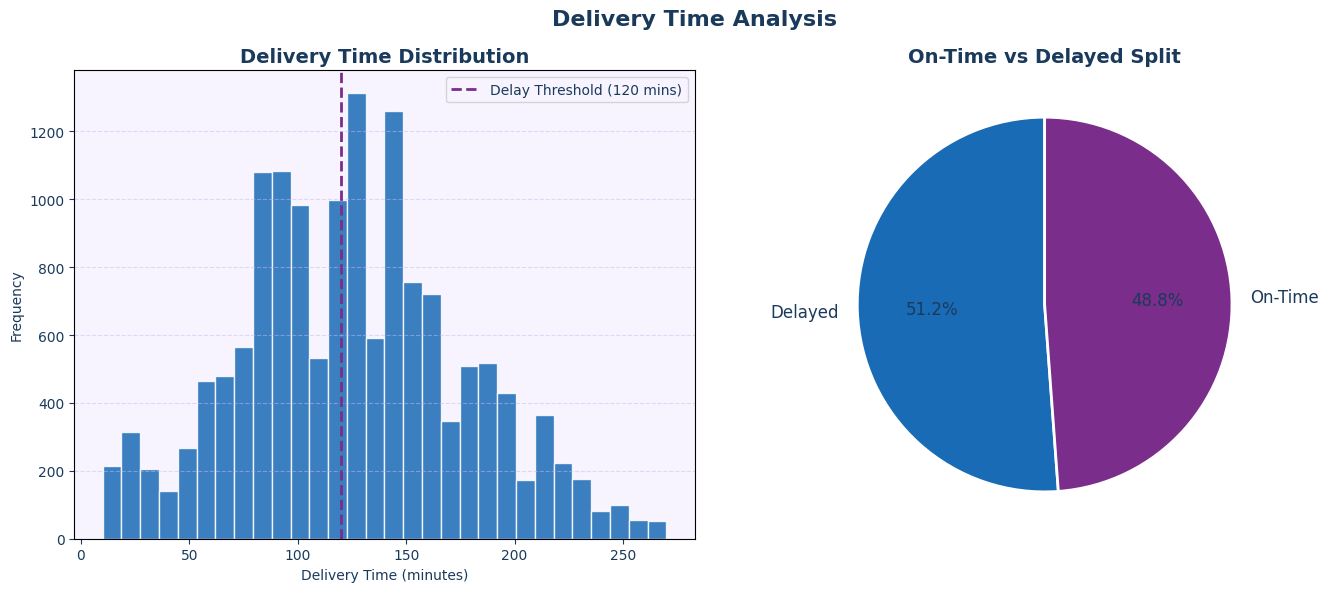

In [21]:
print("=== DELIVERY TIME DISTRIBUTION ===")
print(f"Min  : {df['Delivery_Time'].min()} mins")
print(f"Max  : {df['Delivery_Time'].max()} mins")
print(f"Mean : {df['Delivery_Time'].mean():.2f} mins")
print(f"Median: {df['Delivery_Time'].median()} mins")

# Plot 1 - Histogram
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.patch.set_facecolor('#FFFFFF')

# Histogram
axes[0].hist(
    df['Delivery_Time'],
    bins=30,
    color='#1A6BB5',
    edgecolor='white',
    alpha=0.85
)
axes[0].axvline(
    x=120,
    color='#7B2D8B',
    linewidth=2,
    linestyle='--',
    label='Delay Threshold (120 mins)'
)
axes[0].set_title('Delivery Time Distribution',
                   fontsize=14,
                   fontweight='bold',
                   color='#1A3A5C')
axes[0].set_xlabel('Delivery Time (minutes)', color='#1A3A5C')
axes[0].set_ylabel('Frequency', color='#1A3A5C')
axes[0].set_facecolor('#F8F4FF')
axes[0].grid(axis='y', linestyle='--', alpha=0.5, color='#C5B8F0')
axes[0].legend(fontsize=10)

# Pie Chart
delay_counts = df['Delivery_Status'].value_counts()
axes[1].pie(
    delay_counts,
    labels=delay_counts.index,
    colors=['#1A6BB5', '#7B2D8B'],
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2},
    textprops={'fontsize': 12, 'color': '#1A3A5C'}
)
axes[1].set_title('On-Time vs Delayed Split',
                   fontsize=14,
                   fontweight='bold',
                   color='#1A3A5C')

plt.suptitle('Delivery Time Analysis',
             fontsize=16,
             fontweight='bold',
             color='#1A3A5C')
plt.tight_layout()
plt.show()

=== CORRELATION HEATMAP ===


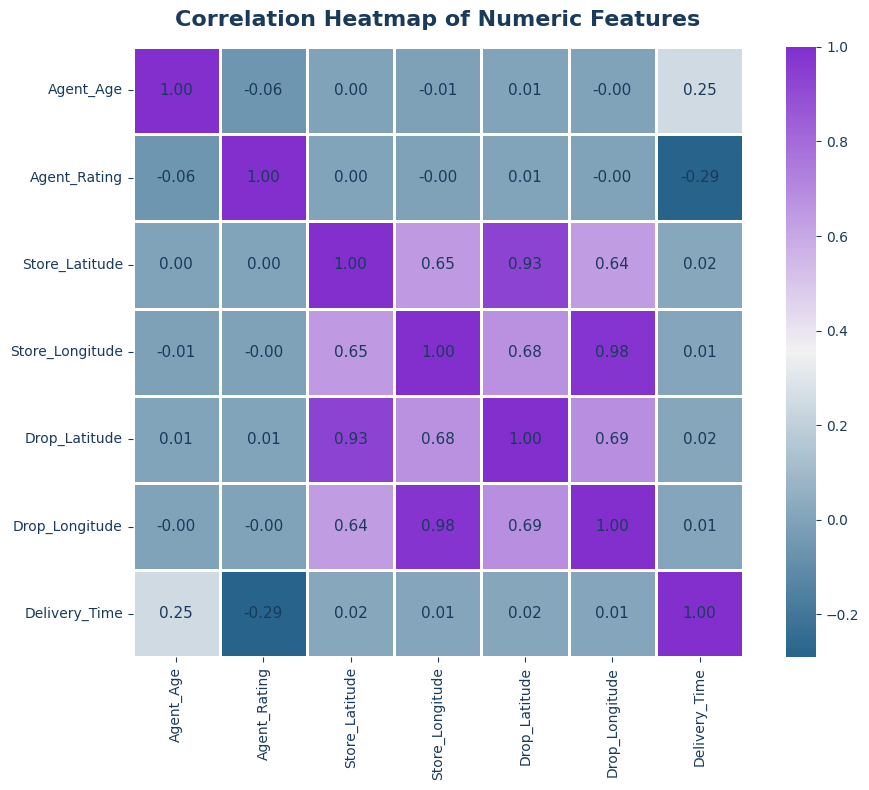

In [22]:
print("=== CORRELATION HEATMAP ===")

numeric_df = df.select_dtypes(include=[np.number])

plt.figure(figsize=(10, 8))
plt.gca().set_facecolor('#F8F4FF')

# Custom blue-purple colormap
cmap = sns.diverging_palette(
    240, 280,
    s=85, l=40,
    as_cmap=True
)

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    fmt='.2f',
    cmap=cmap,
    square=True,
    linewidths=0.8,
    linecolor='white',
    annot_kws={'size': 11, 'color': '#1A3A5C'}
)

plt.title('Correlation Heatmap of Numeric Features',
          fontsize=16,
          fontweight='bold',
          color='#1A3A5C',
          pad=15)
plt.tight_layout()
plt.show()

In [23]:
print("=" * 55)
print("        AMAZON DELIVERY - EDA SUMMARY REPORT")
print("=" * 55)
print(f"\n DATASET OVERVIEW")
print(f"   Total Records    : {len(df):,}")
print(f"   Total Features   : {len(df.columns)}")
print(f"   Missing Values   : {df.isnull().sum().sum()}")
print(f"   Duplicate Rows   : {df.duplicated().sum()}")

print(f"\n DELIVERY STATUS BREAKDOWN")
for status, count in df['Delivery_Status'].value_counts().items():
    pct = count/len(df)*100
    print(f"   {status:10} : {count:,} ({pct:.1f}%)")

print(f"\n  DELIVERY TIME")
print(f"   Minimum  : {df['Delivery_Time'].min()} mins")
print(f"   Maximum  : {df['Delivery_Time'].max()} mins")
print(f"   Average  : {df['Delivery_Time'].mean():.2f} mins")
print(f"   Median   : {df['Delivery_Time'].median()} mins")
print(f"   Threshold: 120 mins")

print(f"\n  WEATHER CONDITIONS")
for w in df['Weather'].unique():
    print(f"   - {w}")

print(f"\n TRAFFIC LEVELS")
for t in df['Traffic'].unique():
    print(f"   - {t}")

print(f"\n VEHICLE TYPES")
for v in df['Vehicle'].unique():
    print(f"   - {v}")

print(f"\n  AREA TYPES")
for a in df['Area'].unique():
    print(f"   - {a}")

print(f"\n PRODUCT CATEGORIES")
for c in df['Category'].unique():
    print(f"   - {c}")

print("\n" + "=" * 55)
print("EDA COMPLETE - READY FOR DATA CLEANING")
print("=" * 55)

        AMAZON DELIVERY - EDA SUMMARY REPORT

 DATASET OVERVIEW
   Total Records    : 15,000
   Total Features   : 17
   Missing Values   : 53
   Duplicate Rows   : 0

 DELIVERY STATUS BREAKDOWN
   Delayed    : 7,675 (51.2%)
   On-Time    : 7,325 (48.8%)

  DELIVERY TIME
   Minimum  : 10 mins
   Maximum  : 270 mins
   Average  : 124.61 mins
   Median   : 125.0 mins
   Threshold: 120 mins

  WEATHER CONDITIONS
   - Stormy
   - Sandstorms
   - Fog
   - Sunny
   - Cloudy
   - Windy
   - nan

 TRAFFIC LEVELS
   - Medium 
   - High 
   - Jam 
   - Low 
   - NaN 

 VEHICLE TYPES
   - motorcycle 
   - scooter 
   - van
   - bicycle 

  AREA TYPES
   - Metropolitian 
   - Urban 
   - Other
   - Semi-Urban 

 PRODUCT CATEGORIES
   - Skincare
   - Grocery
   - Toys
   - Cosmetics
   - Jewelry
   - Snacks
   - Clothing
   - Kitchen
   - Books
   - Apparel
   - Electronics
   - Pet Supplies
   - Shoes
   - Home
   - Sports
   - Outdoors

EDA COMPLETE - READY FOR DATA CLEANING


In [24]:


print("=" * 50)
print("CURRENT DATASET STATE")
print("=" * 50)

# Shape
print(f"\n Shape: {df.shape}")

# Column names and types
print(f"\n Columns & Data Types:")
print(df.dtypes)

# Missing values
print(f"\n Missing Values:")
print(df.isnull().sum())

# Duplicates
print(f"\n Duplicate Rows: {df.duplicated().sum()}")

# Sample data
print(f"\n First 3 Rows:")
df.head(3)

CURRENT DATASET STATE

 Shape: (15000, 17)

 Columns & Data Types:
Order_ID            object
Agent_Age            int64
Agent_Rating       float64
Store_Latitude     float64
Store_Longitude    float64
Drop_Latitude      float64
Drop_Longitude     float64
Order_Date          object
Order_Time          object
Pickup_Time         object
Weather             object
Traffic             object
Vehicle             object
Area                object
Delivery_Time        int64
Category            object
Delivery_Status     object
dtype: object

 Missing Values:
Order_ID            0
Agent_Age           0
Agent_Rating       17
Store_Latitude      0
Store_Longitude     0
Drop_Latitude       0
Drop_Longitude      0
Order_Date          0
Order_Time          0
Pickup_Time         0
Weather            36
Traffic             0
Vehicle             0
Area                0
Delivery_Time       0
Category            0
Delivery_Status     0
dtype: int64

 Duplicate Rows: 0

 First 3 Rows:


,Order_ID,Agent_Age,Agent_Rating,Store_Latitude,Store_Longitude,Drop_Latitude,Drop_Longitude,Order_Date,Order_Time,Pickup_Time,Weather,Traffic,Vehicle,Area,Delivery_Time,Category,Delivery_Status
0,vvgw032244127,29,4.9,11.000762,76.981876,11.050762,77.031876,2022-03-26,17:15:00,17:30:00,Stormy,Medium,motorcycle,Metropolitian,145,Skincare,Delayed
1,fvml427733005,33,4.9,22.760072,75.892574,22.870072,76.002574,2022-03-18,17:15:00,17:25:00,Sandstorms,Medium,scooter,Urban,21,Grocery,On-Time
2,bphh205146945,26,4.7,0.000000,0.000000,0.040000,0.040000,2022-03-21,14:10:00,14:15:00,Fog,High,motorcycle,Metropolitian,165,Toys,Delayed


In [26]:


print("=== BEFORE CLEANING ===")
print(f"Total rows: {len(df)}")
print(f"Missing values:\n{df.isnull().sum()}")

# Fill missing numeric columns with median
numeric_cols = df.select_dtypes(include=['int64','float64']).columns
for col in numeric_cols:
    if df[col].isnull().sum() > 0:
        median_val = df[col].median()
        df[col].fillna(median_val, inplace=True)
        print(f" Filled {col} missing values with median: {median_val}")

# Fill missing categorical columns with mode
categorical_cols = df.select_dtypes(include=['object']).columns
for col in categorical_cols:
    if df[col].isnull().sum() > 0:
        mode_val = df[col].mode()[0]
        df[col].fillna(mode_val, inplace=True)
        print(f" Filled {col} missing values with mode: {mode_val}")

print("\n=== AFTER CLEANING ===")
print(f"Missing values remaining: {df.isnull().sum().sum()}")

=== BEFORE CLEANING ===
Total rows: 15000
Missing values:
Order_ID           0
Agent_Age          0
Agent_Rating       0
Store_Latitude     0
Store_Longitude    0
Drop_Latitude      0
Drop_Longitude     0
Order_Date         0
Order_Time         0
Pickup_Time        0
Weather            0
Traffic            0
Vehicle            0
Area               0
Delivery_Time      0
Category           0
Delivery_Status    0
dtype: int64

=== AFTER CLEANING ===
Missing values remaining: 0


In [27]:


print(f"Rows before removing duplicates: {len(df)}")

# Remove duplicate rows
df = df.drop_duplicates()
df = df.reset_index(drop=True)

print(f"Rows after removing duplicates : {len(df)}")
print(f" Duplicates removed: {len(df)}")

Rows before removing duplicates: 15000
Rows after removing duplicates : 15000
 Duplicates removed: 15000


In [28]:


from sklearn.preprocessing import LabelEncoder

print("=== ENCODING CATEGORICAL COLUMNS ===")
print("Before encoding:")
print(df[['Weather','Traffic','Vehicle',
          'Area','Category','Delivery_Status']].head(3))

# Create a copy for ML
df_ml = df.copy()

# Label encode all categorical columns
le = LabelEncoder()
categorical_cols = ['Weather', 'Traffic', 'Vehicle',
                    'Area', 'Category', 'Delivery_Status']

label_encoders = {}
for col in categorical_cols:
    df_ml[col] = le.fit_transform(df_ml[col])
    label_encoders[col] = le
    print(f" Encoded {col}: {dict(zip(le.classes_, le.transform(le.classes_)))}")

print("\nAfter encoding:")
print(df_ml[['Weather','Traffic','Vehicle',
             'Area','Category','Delivery_Status']].head(3))

=== ENCODING CATEGORICAL COLUMNS ===
Before encoding:
      Weather  Traffic      Vehicle            Area  Category Delivery_Status
0      Stormy  Medium   motorcycle   Metropolitian   Skincare         Delayed
1  Sandstorms  Medium      scooter           Urban    Grocery         On-Time
2         Fog    High   motorcycle   Metropolitian       Toys         Delayed
 Encoded Weather: {'Cloudy': np.int64(0), 'Fog': np.int64(1), 'Sandstorms': np.int64(2), 'Stormy': np.int64(3), 'Sunny': np.int64(4), 'Windy': np.int64(5)}
 Encoded Traffic: {'High ': np.int64(0), 'Jam ': np.int64(1), 'Low ': np.int64(2), 'Medium ': np.int64(3), 'NaN ': np.int64(4)}
 Encoded Vehicle: {'bicycle ': np.int64(0), 'motorcycle ': np.int64(1), 'scooter ': np.int64(2), 'van': np.int64(3)}
 Encoded Area: {'Metropolitian ': np.int64(0), 'Other': np.int64(1), 'Semi-Urban ': np.int64(2), 'Urban ': np.int64(3)}
 Encoded Category: {'Apparel': np.int64(0), 'Books': np.int64(1), 'Clothing': np.int64(2), 'Cosmetics': np.int64(

In [29]:
# Check Order_Time column
print("Order_Time sample values:")
print(df_ml['Order_Time'].head(10).tolist())
print(f"\nMissing values in Order_Time: {df_ml['Order_Time'].isnull().sum()}")
print(f"Data type: {df_ml['Order_Time'].dtype}")

Order_Time sample values:
['17:15:00', '17:15:00', '14:10:00', '19:10:00', '21:35:00', '22:00:00', '21:15:00', '17:40:00', '18:15:00', '08:15:00']

Missing values in Order_Time: 0
Data type: object


In [30]:


print("=== FEATURE ENGINEERING ===")

# Convert Order_Date to datetime
df_ml['Order_Date'] = pd.to_datetime(
    df_ml['Order_Date'],
    errors='coerce'
)

# Extract date features
df_ml['Order_DayOfWeek'] = df_ml['Order_Date'].dt.dayofweek
df_ml['Order_Month']     = df_ml['Order_Date'].dt.month

# Fix Order_Time — handle NaN values first
df_ml['Order_Time'] = df_ml['Order_Time'].astype(str).str.strip()
df_ml['Order_Time'] = df_ml['Order_Time'].replace(
    ['nan', 'NaN', 'None', '', 'NaN '],
    '00:00:00'
)

# Now extract hour safely
df_ml['Order_Hour'] = pd.to_datetime(
    df_ml['Order_Time'],
    format='mixed',
    errors='coerce'
).dt.hour

# Fill any remaining NaN hours with 0
df_ml['Order_Hour'] = df_ml['Order_Hour'].fillna(0).astype(int)

# Calculate distance between store and drop location
df_ml['Distance_KM'] = (
    ((df_ml['Drop_Latitude']  - df_ml['Store_Latitude'])**2 +
     (df_ml['Drop_Longitude'] - df_ml['Store_Longitude'])**2
    )**0.5 * 111
).round(2)

print(" New features created:")
print(f"   - Order_DayOfWeek : {df_ml['Order_DayOfWeek'].unique()}")
print(f"   - Order_Month     : {df_ml['Order_Month'].unique()}")
print(f"   - Order_Hour      : {sorted(df_ml['Order_Hour'].unique())[:5]}")
print(f"   - Distance_KM     : min={df_ml['Distance_KM'].min():.2f}, max={df_ml['Distance_KM'].max():.2f}")
print(f"\n Total features now: {len(df_ml.columns)}")

=== FEATURE ENGINEERING ===
 New features created:
   - Order_DayOfWeek : [5 4 0 6 2 1 3]
   - Order_Month     : [3 4 2]
   - Order_Hour      : [np.int64(0), np.int64(8), np.int64(9), np.int64(10), np.int64(11)]
   - Distance_KM     : min=1.57, max=18779.76

 Total features now: 21


In [31]:



print("=== PREPARING FEATURES & TARGET ===")

# Drop columns not needed for ML
cols_to_drop = [
    'Order_ID',
    'Order_Date',
    'Order_Time',
    'Pickup_Time',
    'Store_Latitude',
    'Store_Longitude',
    'Drop_Latitude',
    'Drop_Longitude',
    'Delivery_Time'
]

df_ml_clean = df_ml.drop(columns=cols_to_drop, errors='ignore')

# Define features (X) and target (y)
X = df_ml_clean.drop(columns=['Delivery_Status'])
y = df_ml_clean['Delivery_Status']

print(f" Features (X) shape : {X.shape}")
print(f" Target  (y) shape  : {y.shape}")
print(f"\n Features used for ML:")
for i, col in enumerate(X.columns, 1):
    print(f"   {i}. {col}")

print(f"\n Target Variable    : Delivery_Status")
print(f"   0 = Delayed")
print(f"   1 = On-Time")
print(f"\n Target Distribution:")
print(y.value_counts())

=== PREPARING FEATURES & TARGET ===
 Features (X) shape : (15000, 11)
 Target  (y) shape  : (15000,)

 Features used for ML:
   1. Agent_Age
   2. Agent_Rating
   3. Weather
   4. Traffic
   5. Vehicle
   6. Area
   7. Category
   8. Order_DayOfWeek
   9. Order_Month
   10. Order_Hour
   11. Distance_KM

 Target Variable    : Delivery_Status
   0 = Delayed
   1 = On-Time

 Target Distribution:
Delivery_Status
0    7675
1    7325
Name: count, dtype: int64


In [32]:


from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

print("=== SPLITTING DATA ===")

# Split into Train (80%) and Test (20%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f" Training set   : {X_train.shape[0]:,} rows (80%)")
print(f" Testing set    : {X_test.shape[0]:,} rows (20%)")
print(f"\n Training Target Distribution:")
print(y_train.value_counts())
print(f"\n Testing Target Distribution:")
print(y_test.value_counts())

# Scale numeric features
print("\n=== SCALING FEATURES ===")
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f" Features scaled successfully!")
print(f"\n=== READY FOR ML MODELS ===")
print(f"X_train : {X_train_scaled.shape}")
print(f"X_test  : {X_test_scaled.shape}")
print(f"y_train : {y_train.shape}")
print(f"y_test  : {y_test.shape}")

=== SPLITTING DATA ===
 Training set   : 12,000 rows (80%)
 Testing set    : 3,000 rows (20%)

 Training Target Distribution:
Delivery_Status
0    6140
1    5860
Name: count, dtype: int64

 Testing Target Distribution:
Delivery_Status
0    1535
1    1465
Name: count, dtype: int64

=== SCALING FEATURES ===
 Features scaled successfully!

=== READY FOR ML MODELS ===
X_train : (12000, 11)
X_test  : (3000, 11)
y_train : (12000,)
y_test  : (3000,)


In [33]:


print("=" * 55)
print("    DATA PREPROCESSING SUMMARY")
print("=" * 55)
print(f"\n Missing values    : Handled (median/mode)")
print(f" Duplicates        : Removed")
print(f" Text → Numbers    : Label Encoding applied")
print(f"\n New Features Created:")
print(f"   - Order_DayOfWeek  (day 0=Mon to 6=Sun)")
print(f"   - Order_Month      (month 1-12)")
print(f"   - Order_Hour       (hour 0-23)")
print(f"   - Distance_KM      (store to drop distance)")
print(f"\n Features (X)      : {X.shape[1]} columns")
print(f" Target (y)        : Delivery_Status")
print(f"\n Data Split:")
print(f"   Training set     : {X_train.shape[0]:,} rows (80%)")
print(f"   Testing set      : {X_test.shape[0]:,} rows (20%)")
print(f"\n Scaling          : StandardScaler applied")
print("=" * 55)
print(" READY FOR STEP 4 - ML MODEL BUILDING!")
print("=" * 55)

    DATA PREPROCESSING SUMMARY

 Missing values    : Handled (median/mode)
 Duplicates        : Removed
 Text → Numbers    : Label Encoding applied

 New Features Created:
   - Order_DayOfWeek  (day 0=Mon to 6=Sun)
   - Order_Month      (month 1-12)
   - Order_Hour       (hour 0-23)
   - Distance_KM      (store to drop distance)

 Features (X)      : 11 columns
 Target (y)        : Delivery_Status

 Data Split:
   Training set     : 12,000 rows (80%)
   Testing set      : 3,000 rows (20%)

 Scaling          : StandardScaler applied
 READY FOR STEP 4 - ML MODEL BUILDING!


In [34]:


# Import all ML libraries
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve
)

import time

print(" All ML libraries imported successfully!")

 All ML libraries imported successfully!


In [35]:
# Import all ML libraries
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve
)

import time

print(" All ML libraries imported successfully!")

 All ML libraries imported successfully!


In [36]:
# ORIGINAL 3 MODELS
# ============================================

print("=" * 55)
print("    ORIGINAL 3 MODELS")
print("=" * 55)

models = {
    'Logistic Regression' : LogisticRegression(
                                max_iter=1000,
                                random_state=42
                            ),
    'Decision Tree'       : DecisionTreeClassifier(
                                random_state=42
                            ),
    'Random Forest'       : RandomForestClassifier(
                                n_estimators=100,
                                random_state=42,
                                n_jobs=-1
                            )
}

results = {}

for model_name, model in models.items():
    print(f"\n Training {model_name}...")

    start_time = time.time()
    model.fit(X_train_scaled, y_train)

    y_pred      = model.predict(X_test_scaled)
    y_pred_prob = model.predict_proba(X_test_scaled)[:, 1]

    test_acc   = accuracy_score(y_test, y_pred)
    train_acc  = accuracy_score(
                     y_train,
                     model.predict(X_train_scaled)
                 )
    roc_auc    = roc_auc_score(y_test, y_pred_prob)
    train_time = time.time() - start_time
    diff       = train_acc - test_acc

    results[model_name] = {
        'model'       : model,
        'y_pred'      : y_pred,
        'y_pred_prob' : y_pred_prob,
        'accuracy'    : test_acc,
        'train_acc'   : train_acc,
        'roc_auc'     : roc_auc,
        'train_time'  : train_time
    }

    print(f"    Train Accuracy : {train_acc*100:.2f}%")
    print(f"    Test Accuracy  : {test_acc*100:.2f}%")
    print(f"    ROC AUC        : {roc_auc:.4f}")
    print(f"    Train-Test Gap : {diff*100:.2f}%")
    print(f"    Time           : {train_time:.2f} seconds")

    if diff > 0.10:
        print(f"     Overfitting detected!")
    else:
        print(f"    No overfitting!")

print("\n" + "=" * 55)
print(" ORIGINAL MODELS COMPLETE!")
print("=" * 55)

results_original = {
    'Logistic Regression': {
        'train_acc': 0.6849,
        'accuracy' : 0.6787
    },
    'Decision Tree': {
        'train_acc': 1.0000,
        'accuracy' : 0.7990
    },
    'Random Forest': {
        'train_acc': 1.0000,
        'accuracy' : 0.8313
    }
}

    ORIGINAL 3 MODELS

 Training Logistic Regression...
    Train Accuracy : 68.49%
    Test Accuracy  : 67.87%
    ROC AUC        : 0.7474
    Train-Test Gap : 0.62%
    Time           : 0.07 seconds
    No overfitting!

 Training Decision Tree...
    Train Accuracy : 100.00%
    Test Accuracy  : 79.90%
    ROC AUC        : 0.7988
    Train-Test Gap : 20.10%
    Time           : 0.11 seconds
     Overfitting detected!

 Training Random Forest...
    Train Accuracy : 100.00%
    Test Accuracy  : 83.13%
    ROC AUC        : 0.9183
    Train-Test Gap : 16.87%
    Time           : 2.48 seconds
     Overfitting detected!

 ORIGINAL MODELS COMPLETE!


In [37]:
# TUNED 3 MODELS (Overfitting Fixed)
# ============================================

print("=" * 55)
print(" 🔧 TUNED 3 MODELS (Overfitting Fixed)")
print("=" * 55)

models_tuned = {
    'Logistic Regression' : LogisticRegression(
                                max_iter=1000,
                                random_state=42
                            ),
    'Decision Tree'       : DecisionTreeClassifier(
                                max_depth=6,
                                min_samples_split=20,
                                min_samples_leaf=10,
                                random_state=42
                            ),
    'Random Forest'       : RandomForestClassifier(
                                n_estimators=200,
                                max_depth=8,
                                min_samples_split=20,
                                min_samples_leaf=10,
                                random_state=42,
                                n_jobs=-1
                            )
}

results_tuned = {}

for model_name, model in models_tuned.items():
    print(f"\n Training Tuned {model_name}...")

    start_time = time.time()
    model.fit(X_train_scaled, y_train)

    y_pred      = model.predict(X_test_scaled)
    y_pred_prob = model.predict_proba(X_test_scaled)[:, 1]

    test_acc   = accuracy_score(y_test, y_pred)
    train_acc  = accuracy_score(
                     y_train,
                     model.predict(X_train_scaled)
                 )
    roc_auc    = roc_auc_score(y_test, y_pred_prob)
    train_time = time.time() - start_time
    diff       = train_acc - test_acc

    results_tuned[model_name] = {
        'model'       : model,
        'y_pred'      : y_pred,
        'y_pred_prob' : y_pred_prob,
        'accuracy'    : test_acc,
        'train_acc'   : train_acc,
        'roc_auc'     : roc_auc,
        'train_time'  : train_time
    }

    print(f"    Train Accuracy : {train_acc*100:.2f}%")
    print(f"    Test Accuracy  : {test_acc*100:.2f}%")
    print(f"    ROC AUC        : {roc_auc:.4f}")
    print(f"    Train-Test Gap : {diff*100:.2f}%")
    print(f"     Time           : {train_time:.2f} seconds")

    if diff > 0.10:
        print(f"     Still overfitting!")
    else:
        print(f"    Overfitting fixed!")

results = results_tuned

print("\n" + "=" * 55)
print(" TUNED MODELS COMPLETE!")
print("=" * 55)


 🔧 TUNED 3 MODELS (Overfitting Fixed)

 Training Tuned Logistic Regression...
    Train Accuracy : 68.49%
    Test Accuracy  : 67.87%
    ROC AUC        : 0.7474
    Train-Test Gap : 0.62%
     Time           : 0.04 seconds
    Overfitting fixed!

 Training Tuned Decision Tree...
    Train Accuracy : 80.82%
    Test Accuracy  : 80.33%
    ROC AUC        : 0.8965
    Train-Test Gap : 0.48%
     Time           : 0.07 seconds
    Overfitting fixed!

 Training Tuned Random Forest...
    Train Accuracy : 82.79%
    Test Accuracy  : 81.03%
    ROC AUC        : 0.9080
    Train-Test Gap : 1.76%
     Time           : 4.27 seconds
    Overfitting fixed!

 TUNED MODELS COMPLETE!


In [38]:
# COMPARISON TABLE — ORIGINAL vs TUNED
# ============================================

print("=" * 75)
print("    ORIGINAL vs TUNED MODEL COMPARISON")
print("=" * 75)
print(f"\n{'Model':<22} {'Orig Train':>10} {'Orig Test':>10} "
      f"{'Tuned Train':>12} {'Tuned Test':>11} {'Gap':>8}")
print("-" * 75)

for model_name in results_tuned.keys():
    orig_train  = results_original[model_name]['train_acc'] * 100
    orig_test   = results_original[model_name]['accuracy'] * 100
    tuned_train = results_tuned[model_name]['train_acc'] * 100
    tuned_test  = results_tuned[model_name]['accuracy'] * 100
    gap         = tuned_train - tuned_test

    print(f"{model_name:<22} "
          f"{orig_train:>9.2f}% "
          f"{orig_test:>9.2f}% "
          f"{tuned_train:>11.2f}% "
          f"{tuned_test:>10.2f}% "
          f"{gap:>7.2f}%")

print("-" * 75)

best_tuned = max(
    results_tuned,
    key=lambda x: results_tuned[x]['accuracy']
)

print(f"\n BEST MODEL  : {best_tuned}")
print(f" ACCURACY    : {results_tuned[best_tuned]['accuracy']*100:.2f}%")
print(f" ROC AUC     : {results_tuned[best_tuned]['roc_auc']:.4f}")
print(f"\n Using tuned results for all analysis!")
print("=" * 75)

    ORIGINAL vs TUNED MODEL COMPARISON

Model                  Orig Train  Orig Test  Tuned Train  Tuned Test      Gap
---------------------------------------------------------------------------
Logistic Regression        68.49%     67.87%       68.49%      67.87%    0.62%
Decision Tree             100.00%     79.90%       80.82%      80.33%    0.48%
Random Forest             100.00%     83.13%       82.79%      81.03%    1.76%
---------------------------------------------------------------------------

 BEST MODEL  : Random Forest
 ACCURACY    : 81.03%
 ROC AUC     : 0.9080

 Using tuned results for all analysis!


In [39]:
# CLASSIFICATION REPORTS
# ============================================

print("=" * 55)
print("  CLASSIFICATION REPORTS")
print("=" * 55)

for model_name, result in results_tuned.items():
    print(f"\n{'='*55}")
    print(f"{model_name}")
    print(f"{'='*55}")
    print(classification_report(
        y_test,
        result['y_pred'],
        target_names=['Delayed (0)', 'On-Time (1)']
    ))

  CLASSIFICATION REPORTS

Logistic Regression
              precision    recall  f1-score   support

 Delayed (0)       0.69      0.68      0.69      1535
 On-Time (1)       0.67      0.67      0.67      1465

    accuracy                           0.68      3000
   macro avg       0.68      0.68      0.68      3000
weighted avg       0.68      0.68      0.68      3000


Decision Tree
              precision    recall  f1-score   support

 Delayed (0)       0.90      0.70      0.78      1535
 On-Time (1)       0.74      0.92      0.82      1465

    accuracy                           0.80      3000
   macro avg       0.82      0.81      0.80      3000
weighted avg       0.82      0.80      0.80      3000


Random Forest
              precision    recall  f1-score   support

 Delayed (0)       0.86      0.75      0.80      1535
 On-Time (1)       0.77      0.87      0.82      1465

    accuracy                           0.81      3000
   macro avg       0.82      0.81      0.81      300

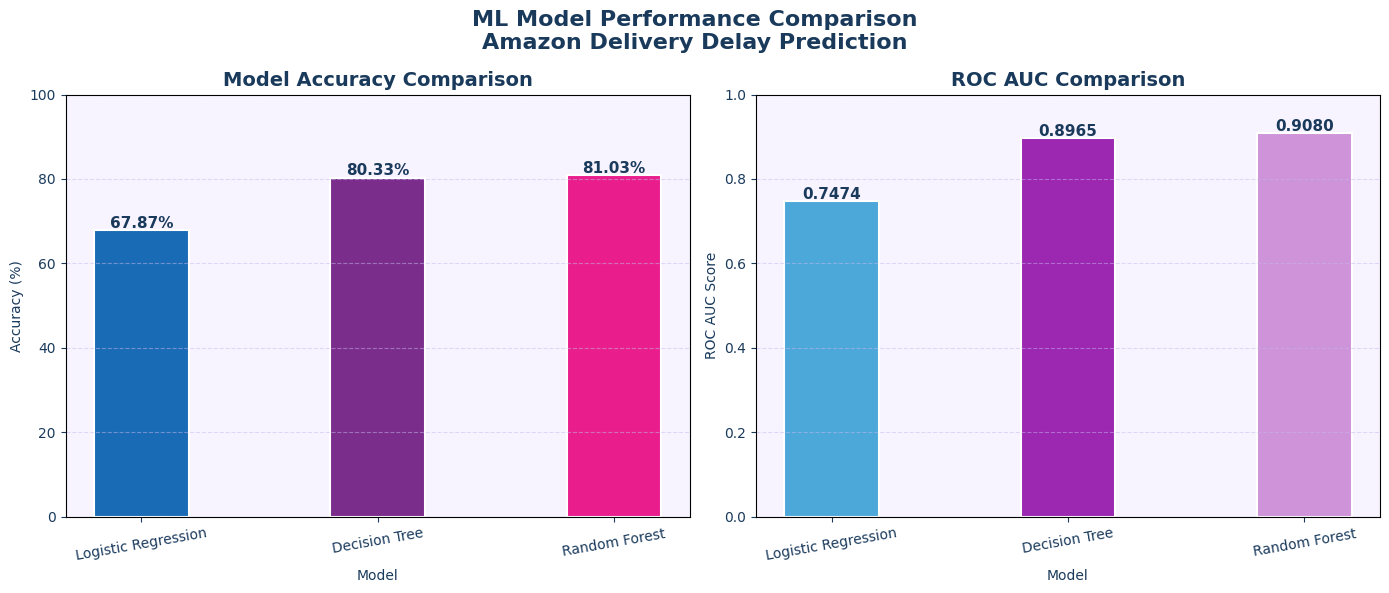

Chart saved!


In [40]:
# MODEL COMPARISON CHART
# ============================================

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.patch.set_facecolor('#FFFFFF')

model_names = list(results_tuned.keys())
accuracies  = [results_tuned[m]['accuracy'] * 100
               for m in model_names]
roc_aucs    = [results_tuned[m]['roc_auc']
               for m in model_names]

# Chart 1 — Accuracy
bars1 = axes[0].bar(
    model_names,
    accuracies,
    color=['#1A6BB5', '#7B2D8B', '#E91E8C'],
    edgecolor='white',
    linewidth=1.5,
    width=0.4
)
axes[0].set_title('Model Accuracy Comparison',
                   fontsize=14, fontweight='bold',
                   color='#1A3A5C')
axes[0].set_xlabel('Model', color='#1A3A5C')
axes[0].set_ylabel('Accuracy (%)', color='#1A3A5C')
axes[0].set_ylim(0, 100)
axes[0].set_facecolor('#F8F4FF')
axes[0].grid(axis='y', linestyle='--',
             alpha=0.5, color='#C5B8F0')
axes[0].tick_params(axis='x', rotation=10)

for bar, acc in zip(bars1, accuracies):
    axes[0].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.5,
        f'{acc:.2f}%',
        ha='center', fontweight='bold',
        fontsize=11, color='#1A3A5C'
    )

# Chart 2 — ROC AUC
bars2 = axes[1].bar(
    model_names,
    roc_aucs,
    color=['#4DA8DA', '#9C27B0', '#CE93D8'],
    edgecolor='white',
    linewidth=1.5,
    width=0.4
)
axes[1].set_title('ROC AUC Comparison',
                   fontsize=14, fontweight='bold',
                   color='#1A3A5C')
axes[1].set_xlabel('Model', color='#1A3A5C')
axes[1].set_ylabel('ROC AUC Score', color='#1A3A5C')
axes[1].set_ylim(0, 1)
axes[1].set_facecolor('#F8F4FF')
axes[1].grid(axis='y', linestyle='--',
             alpha=0.5, color='#C5B8F0')
axes[1].tick_params(axis='x', rotation=10)

for bar, auc in zip(bars2, roc_aucs):
    axes[1].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.005,
        f'{auc:.4f}',
        ha='center', fontweight='bold',
        fontsize=11, color='#1A3A5C'
    )

plt.suptitle(
    'ML Model Performance Comparison\n'
    'Amazon Delivery Delay Prediction',
    fontsize=16, fontweight='bold',
    color='#1A3A5C'
)
plt.tight_layout()
plt.savefig('model_comparison.png',
            dpi=300, bbox_inches='tight')
plt.show()
print("Chart saved!")

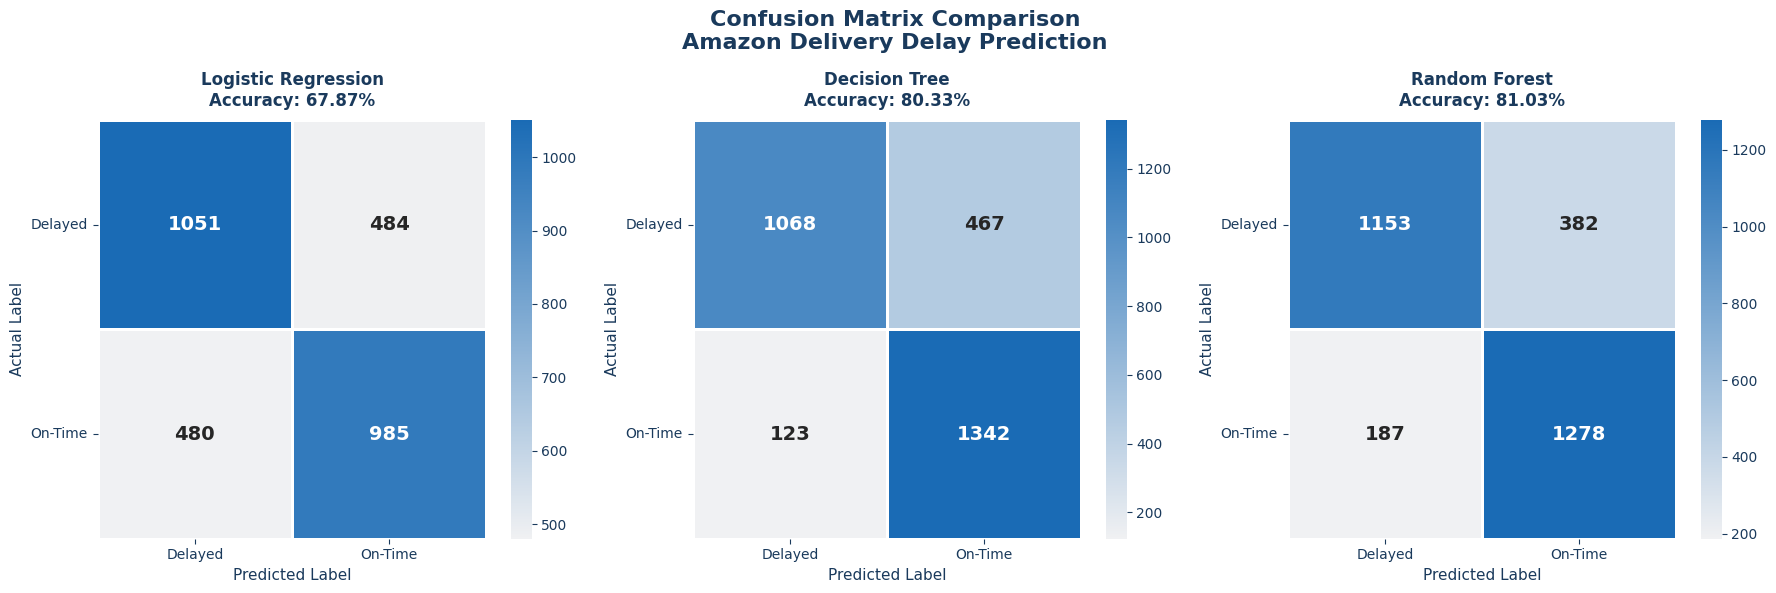

Confusion Matrix saved!


In [41]:
# CONFUSION MATRIX
# ============================================

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.patch.set_facecolor('#FFFFFF')

cmap = sns.light_palette('#1A6BB5', as_cmap=True)

for idx, (model_name, result) in enumerate(results_tuned.items()):

    cm = confusion_matrix(y_test, result['y_pred'])

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap=cmap,
        ax=axes[idx],
        linewidths=2,
        linecolor='white',
        annot_kws={'size': 14, 'fontweight': 'bold'}
    )

    axes[idx].set_title(
        f'{model_name}\n'
        f'Accuracy: {result["accuracy"]*100:.2f}%',
        fontsize=12, fontweight='bold',
        color='#1A3A5C', pad=10
    )
    axes[idx].set_xlabel('Predicted Label',
        fontsize=11, color='#1A3A5C')
    axes[idx].set_ylabel('Actual Label',
        fontsize=11, color='#1A3A5C')
    axes[idx].set_xticklabels(
        ['Delayed', 'On-Time'], fontsize=10)
    axes[idx].set_yticklabels(
        ['Delayed', 'On-Time'], fontsize=10,
        rotation=0)
    axes[idx].set_facecolor('#F8F4FF')

plt.suptitle(
    'Confusion Matrix Comparison\n'
    'Amazon Delivery Delay Prediction',
    fontsize=16, fontweight='bold',
    color='#1A3A5C'
)
plt.tight_layout()
plt.savefig('confusion_matrix.png',
            dpi=300, bbox_inches='tight')
plt.show()
print("Confusion Matrix saved!")

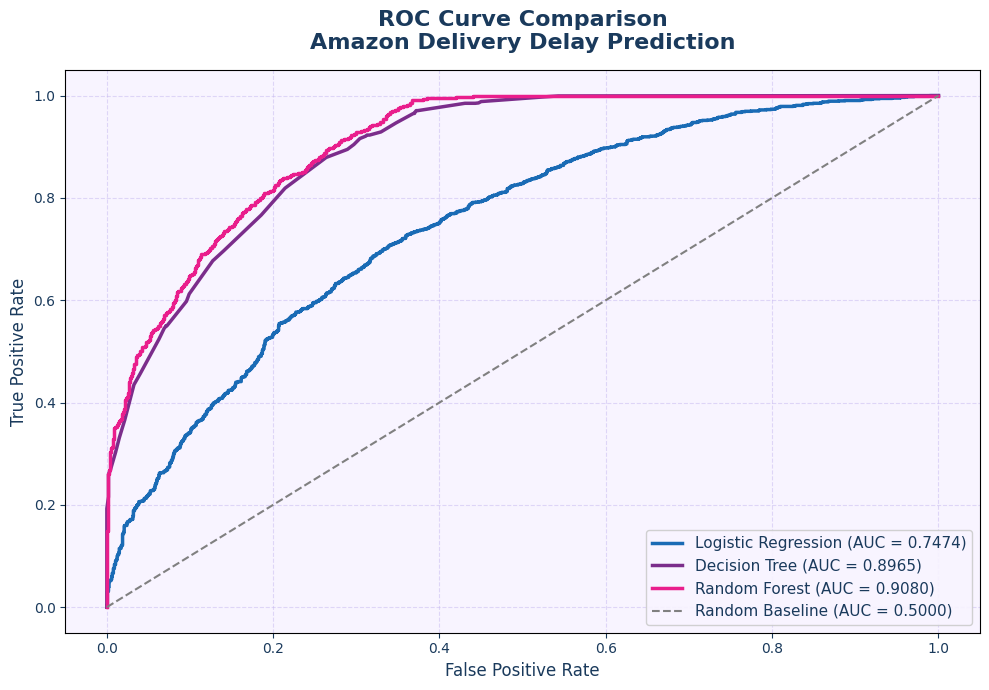

ROC Curve saved!


In [42]:
# ROC CURVE
# ============================================

plt.figure(figsize=(10, 7))
plt.gca().set_facecolor('#F8F4FF')
fig = plt.gcf()
fig.patch.set_facecolor('#FFFFFF')

roc_colors = ['#1A6BB5', '#7B2D8B', '#E91E8C']

for idx, (model_name, result) in enumerate(results_tuned.items()):

    fpr, tpr, _ = roc_curve(
        y_test,
        result['y_pred_prob']
    )
    auc_score = result['roc_auc']

    plt.plot(
        fpr, tpr,
        color=roc_colors[idx],
        linewidth=2.5,
        label=f'{model_name} (AUC = {auc_score:.4f})'
    )

# Random baseline
plt.plot(
    [0, 1], [0, 1],
    color='gray',
    linewidth=1.5,
    linestyle='--',
    label='Random Baseline (AUC = 0.5000)'
)

plt.title(
    'ROC Curve Comparison\n'
    'Amazon Delivery Delay Prediction',
    fontsize=16, fontweight='bold',
    color='#1A3A5C', pad=15
)
plt.xlabel('False Positive Rate',
    fontsize=12, color='#1A3A5C')
plt.ylabel('True Positive Rate',
    fontsize=12, color='#1A3A5C')
plt.legend(loc='lower right', fontsize=11,
    framealpha=0.9)
plt.grid(linestyle='--', alpha=0.5,
    color='#C5B8F0')
plt.tight_layout()
plt.savefig('roc_curve.png',
    dpi=300, bbox_inches='tight')
plt.show()
print("ROC Curve saved!")

=== FEATURE IMPORTANCE (Random Forest) ===
            Feature  Importance
0         Agent_Age    0.191985
1      Agent_Rating    0.177977
2           Weather    0.160195
3           Traffic    0.140741
9        Order_Hour    0.106258
10      Distance_KM    0.093167
6          Category    0.071770
5              Area    0.024717
4           Vehicle    0.021863
7   Order_DayOfWeek    0.007999
8       Order_Month    0.003329


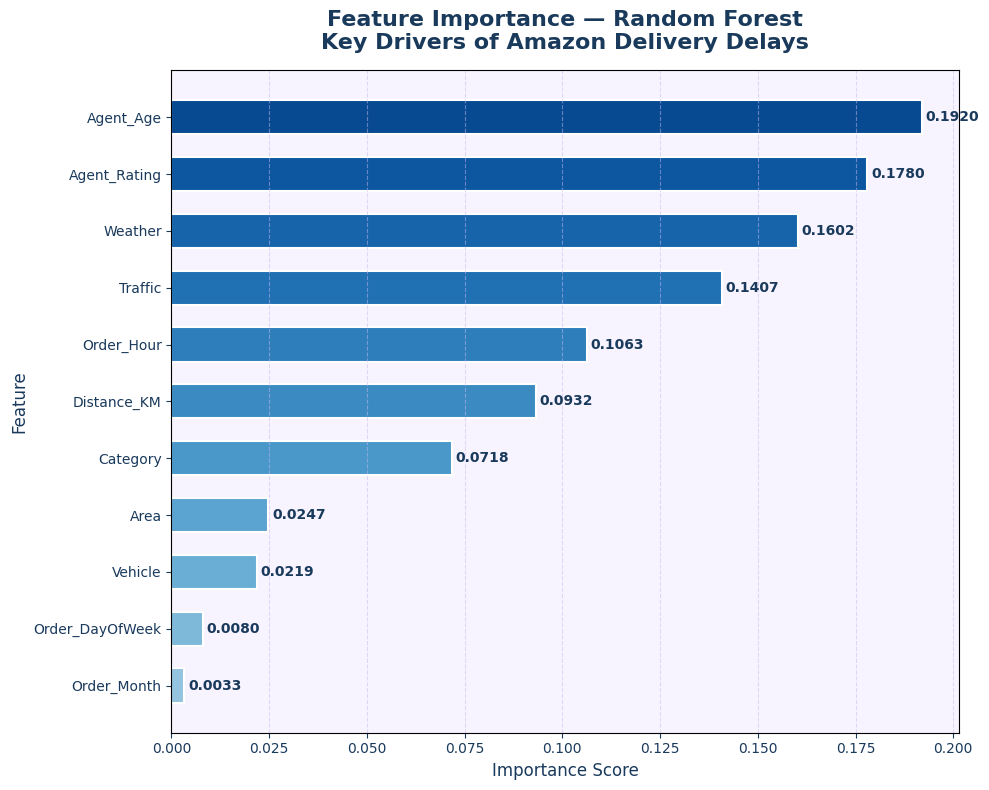

Feature Importance saved!


In [43]:
# FEATURE IMPORTANCE
# ============================================

rf_model      = results_tuned['Random Forest']['model']
feature_names = X.columns.tolist()
importances   = rf_model.feature_importances_

# Create dataframe
feat_df = pd.DataFrame({
    'Feature'   : feature_names,
    'Importance': importances
}).sort_values('Importance', ascending=True)

print("=== FEATURE IMPORTANCE (Random Forest) ===")
print(feat_df.sort_values(
    'Importance', ascending=False
).to_string())

# Plot
fig, ax = plt.subplots(figsize=(10, 8))
fig.patch.set_facecolor('#FFFFFF')
ax.set_facecolor('#F8F4FF')

colors = plt.cm.Blues(
    np.linspace(0.4, 0.9, len(feat_df))
)

bars = ax.barh(
    feat_df['Feature'],
    feat_df['Importance'],
    color=colors,
    edgecolor='white',
    linewidth=1.5,
    height=0.6
)

for bar, val in zip(bars, feat_df['Importance']):
    ax.text(
        bar.get_width() + 0.001,
        bar.get_y() + bar.get_height()/2,
        f'{val:.4f}',
        va='center', fontsize=10,
        fontweight='bold', color='#1A3A5C'
    )

ax.set_title(
    'Feature Importance — Random Forest\n'
    'Key Drivers of Amazon Delivery Delays',
    fontsize=16, fontweight='bold',
    color='#1A3A5C', pad=15
)
ax.set_xlabel('Importance Score',
    fontsize=12, color='#1A3A5C')
ax.set_ylabel('Feature',
    fontsize=12, color='#1A3A5C')
ax.grid(axis='x', linestyle='--',
    alpha=0.5, color='#C5B8F0')
plt.tight_layout()
plt.savefig('feature_importance.png',
    dpi=300, bbox_inches='tight')
plt.show()
print("Feature Importance saved!")

In [44]:
# EXPORT ALL FILES
# ============================================

from google.colab import files
import pandas as pd

print("=== EXPORTING FILES ===")

# 1. Cleaned dataset
df.to_csv('Amazon_Delivery_Clean.csv', index=False)
print("1. Amazon_Delivery_Clean.csv created")
files.download('Amazon_Delivery_Clean.csv')

# 2. Model results
model_results_df = pd.DataFrame({
    'Model'          : list(results_tuned.keys()),
    'Train_Accuracy' : [results_tuned[m]['train_acc']*100
                        for m in results_tuned],
    'Test_Accuracy'  : [results_tuned[m]['accuracy']*100
                        for m in results_tuned],
    'ROC_AUC'        : [results_tuned[m]['roc_auc']
                        for m in results_tuned],
})
model_results_df.to_csv('Model_Results.csv', index=False)
print(" 2. Model_Results.csv created")
files.download('Model_Results.csv')

# 3. Feature importance
feat_df.to_csv('Feature_Importance.csv', index=False)
print(" 3. Feature_Importance.csv created")
files.download('Feature_Importance.csv')

# 4. Predictions
predictions_df = pd.DataFrame({
    'Actual'         : y_test.values,
    'LR_Predicted'   : results_tuned['Logistic Regression']['y_pred'],
    'DT_Predicted'   : results_tuned['Decision Tree']['y_pred'],
    'RF_Predicted'   : results_tuned['Random Forest']['y_pred'],
    'RF_Probability' : results_tuned['Random Forest']['y_pred_prob']
})
predictions_df.to_csv('Model_Predictions.csv', index=False)
print("4. Model_Predictions.csv created")
files.download('Model_Predictions.csv')

# Download charts
files.download('model_comparison.png')
files.download('confusion_matrix.png')
files.download('roc_curve.png')
files.download('feature_importance.png')

print("\n ALL FILES DOWNLOADED!")

=== EXPORTING FILES ===
1. Amazon_Delivery_Clean.csv created


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

 2. Model_Results.csv created


<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


 ALL FILES DOWNLOADED!
